# Supplementary: Cross-architecture explanation comparison

> Standalone study (not duplicated in the three main tutorials). See `tutorial_01_player_masker_strategies.ipynb` for per-architecture masking defaults and `tutorial_03_benchmarks_and_comparison.ipynb` for wall-clock benchmarks.

# Cross-architecture explanation comparison

**Do different vision architectures find the same evidence in the same image?**

## Abstract

Different vision architectures encode different inductive biases. CNNs (ResNet, ConvNeXt) build representations from local receptive fields, while transformers (ViT, DINOv2, CLIP) operate on flat token sequences with global attention. If a model's *decision* depends on a particular region of an image, does its *inductive bias* determine where the relevant evidence lives, even when the inputs and the partition of the image into players are identical?

To answer this, we hold every other variable fixed:

- **one image** (same superpixel partition)
- **one player strategy** (`SuperpixelStrategy(n_segments=10)`)
- **one masking strategy** (`MeanColorMasking` in pixel space, applied identically to every architecture)

and vary only the model: ResNet-18, ConvNeXt-tiny, ViT-B/16 under pixel-space masking, DINOv2-small (feature similarity), and CLIP-B/32 (zero-shot text-prompt probability).

We compute **exact** first-order Shapley values (10 players, $2^{10}=1024$ coalitions per model) and analyse the pairwise rank correlation across all five architectures, whether CNN- and transformer-family models cluster together, and which superpixels produce the largest disagreement across architectures.

## Why the masking strategy is held constant

Different architectures support different masking primitives (for example, ViT supports `bool_masked_pos` while CLIP does not). To allow a fair comparison, every model is given the same pixel-space masker. This means we are not necessarily explaining each model in its most natural form, but the experimental control is what makes the comparison interpretable.

## 1. Setup


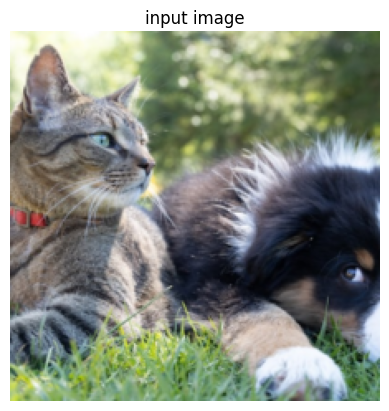

In [20]:
from __future__ import annotations

from io import BytesIO

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from matplotlib import cm
from PIL import Image
from torchvision import models, transforms

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

URL = (
    "https://images.unsplash.com/photo-1623387641168-d9803ddd3f35?"
    "q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0"
)
raw = Image.open(BytesIO(requests.get(URL, timeout=30).content)).convert("RGB")
pil_image = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])(raw)
image = np.array(pil_image)
plt.imshow(image)
plt.axis("off")
plt.title("input image")
plt.show()

### Common player partition

We compute the SLIC superpixels **once** and reuse the same `FixedMasksStrategy` for every architecture below. This is the experimental control: all five architectures operate on identical players.


superpixel masks shape: (10, 224, 224)   unique pixels: 1


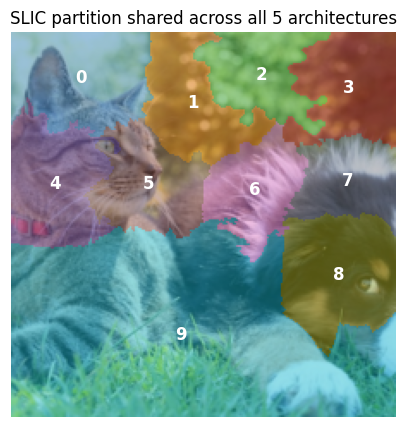

In [21]:
from shapiq.vision import SuperpixelStrategy
from shapiq.vision.players import PixelPlayerStrategy

N_PLAYERS = 10
slic = SuperpixelStrategy(n_segments=N_PLAYERS)
_player_masks = slic.get_masks(image)  # (10, H, W)
print(
    "superpixel masks shape:",
    _player_masks.shape,
    "  unique pixels:",
    _player_masks.sum(axis=0).max(),
)


class FixedSLIC(PixelPlayerStrategy):
    """Wraps the pre-computed SLIC masks so every architecture uses identical players."""

    def get_masks(self, _img):
        return _player_masks

    @property
    def n_players(self):
        return int(_player_masks.shape[0])


def show_partition():
    seg = (_player_masks * (np.arange(N_PLAYERS) + 1)[:, None, None]).sum(0)
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.imshow(seg, cmap="tab10", alpha=0.45)
    for i in range(N_PLAYERS):
        ys, xs = np.where(_player_masks[i])
        plt.text(
            xs.mean(),
            ys.mean(),
            str(i),
            color="w",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
        )
    plt.axis("off")
    plt.title("SLIC partition shared across all 5 architectures")
    plt.show()


show_partition()

## 2. Build the five architectures

Every architecture uses `MeanColorMasking` in pixel space. Differences below are *only* the model.


In [22]:
from transformers import (
    AutoImageProcessor,
    AutoModel,
    CLIPModel,
    CLIPProcessor,
    ConvNextForImageClassification,
    ViTForImageClassification,
    ViTImageProcessor,
)

from shapiq.vision import (
    CLIPArchitecture,
    ConvNeXtArchitecture,
    DINOv2Architecture,
    HuggingFacePixelArchitecture,
    ResNetArchitecture,
)
from shapiq.vision.masking import MeanColorMasking

# ----- ResNet18 (torchvision) wrapped as a numpy callable -----
weights = models.ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=weights).eval().to(device)
rs_preprocess = transforms.Compose([transforms.ToTensor(), weights.transforms()])
with torch.no_grad():
    rs_class = int(resnet(rs_preprocess(pil_image).unsqueeze(0).to(device)).argmax(-1).item())


def resnet_model(batch_hwc):
    pil = [Image.fromarray(a.astype(np.uint8)) for a in batch_hwc]
    t = torch.stack([rs_preprocess(im) for im in pil]).to(device)
    with torch.no_grad():
        return resnet(t)[:, rs_class].cpu().numpy()


arch_resnet = ResNetArchitecture(model=resnet_model, masking_strategy=MeanColorMasking())

# ----- ConvNeXt-tiny -----
cnx_id = "facebook/convnext-tiny-224"
arch_convnext = ConvNeXtArchitecture(
    model=ConvNextForImageClassification.from_pretrained(cnx_id).eval().to(device),
    processor=AutoImageProcessor.from_pretrained(cnx_id),
    masking_strategy=MeanColorMasking(),
)

# ----- ViT-B/16 under PIXEL-space masking (HuggingFacePixelArchitecture) -----
vit_id = "google/vit-base-patch16-224"
arch_vit_pixel = HuggingFacePixelArchitecture(
    model=ViTForImageClassification.from_pretrained(vit_id).eval().to(device),
    processor=ViTImageProcessor.from_pretrained(vit_id),
    masking_strategy=MeanColorMasking(),
)

# ----- DINOv2-small (feature similarity, no classification head) -----
dino_id = "facebook/dinov2-small"
arch_dino = DINOv2Architecture(
    model=AutoModel.from_pretrained(dino_id).eval().to(device),
    processor=AutoImageProcessor.from_pretrained(dino_id),
    masking_strategy=MeanColorMasking(),
)

# ----- CLIP-B/32 (zero-shot prompt probability) -----
clip_id = "openai/clip-vit-base-patch32"
PROMPTS = ["a photo of a cat", "a photo of a dog", "a photo of a car", "a photo of a tree"]
arch_clip = CLIPArchitecture(
    model=CLIPModel.from_pretrained(clip_id).eval().to(device),
    processor=CLIPProcessor.from_pretrained(clip_id),
    text_prompts=PROMPTS,
    target_prompt_idx=0,
    masking_strategy=MeanColorMasking(),
)

architectures = {
    "ResNet18": arch_resnet,
    "ConvNeXt-tiny": arch_convnext,
    "ViT-B/16 (pixel)": arch_vit_pixel,
    "DINOv2-small": arch_dino,
    "CLIP-B/32": arch_clip,
}
print("loaded", len(architectures), "architectures")

Loading weights:   0%|          | 0/182 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


loaded 5 architectures


## 3. Compute exact first-order Shapley values for each architecture

10 players ⇒ 1024 coalitions per model. We use `batch_size=16` so GPU memory stays modest.


In [23]:
from shapiq.game_theory.exact import ExactComputer
from shapiq.vision.imputer import ImageImputer

sv_per_arch = {}
for name, arch in architectures.items():
    imp = ImageImputer(
        architecture=arch,
        image=image,
        player_strategy=FixedSLIC(),
        batch_size=16,
        normalize=False,
    )
    ec = ExactComputer(n_players=N_PLAYERS, game=imp)
    sv = ec.probabilistic_value(index="SV")
    sv_per_arch[name] = np.array([sv[(i,)] for i in range(N_PLAYERS)])
    print(f"  {name:<20} done.  v(empty)={float(ec.baseline_value):+.4f}")

  ResNet18             done.  v(empty)=+0.7340
  ConvNeXt-tiny        done.  v(empty)=+0.0009
  ViT-B/16 (pixel)     done.  v(empty)=+0.0002
  DINOv2-small         done.  v(empty)=-0.0548
  CLIP-B/32            done.  v(empty)=+0.2508


## 4. Visualize: per-architecture attribution maps


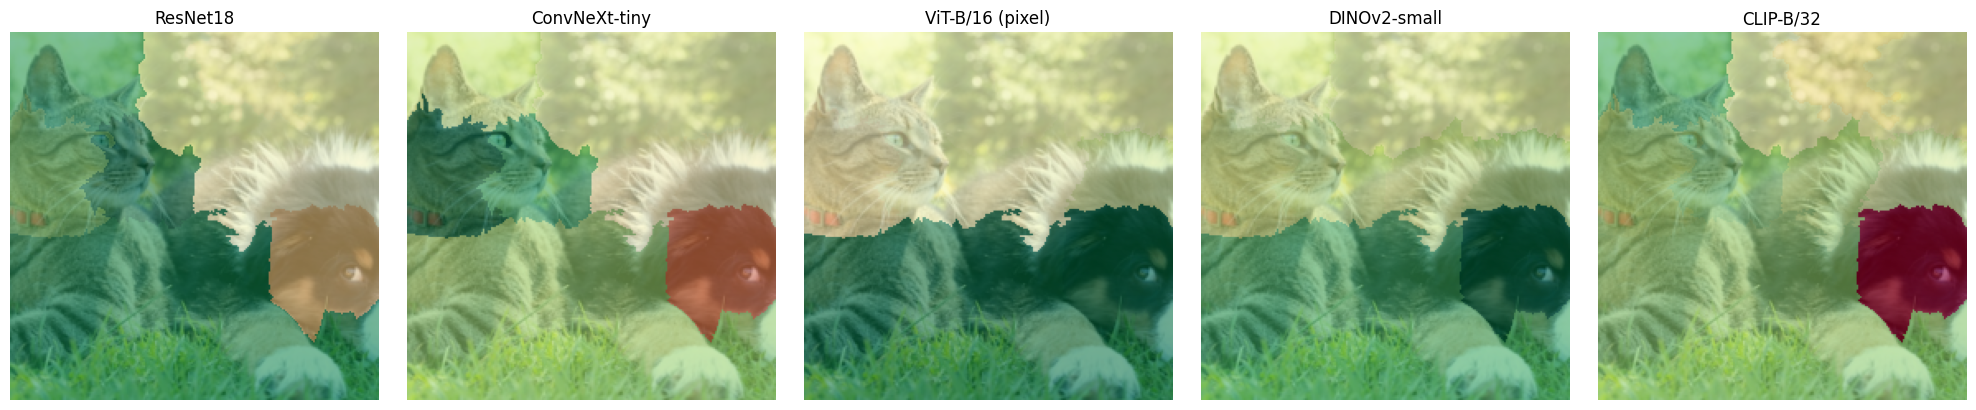

In [24]:
def heatmap_from_masks(values):
    h = np.zeros(image.shape[:2])
    for i, v in enumerate(values):
        h[_player_masks[i]] = v
    return h


fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, sv) in zip(axes, sv_per_arch.items(), strict=False):
    h = heatmap_from_masks(sv)
    v = max(abs(h.min()), abs(h.max())) + 1e-9
    ax.imshow(image)
    ax.imshow(h, cmap=cm.RdYlGn, norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-v, vmax=v), alpha=0.55)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Pairwise rank correlation

The five architectures operate on different output scales (CLIP returns a softmax probability in $[0,1]$, DINOv2 returns a cosine similarity in $[-1,1]$, and the classifier models return raw class scores). Their **rankings** are still comparable: which superpixel is considered most or least important?

We use Spearman rank correlation $\rho$ over the 10 superpixels.


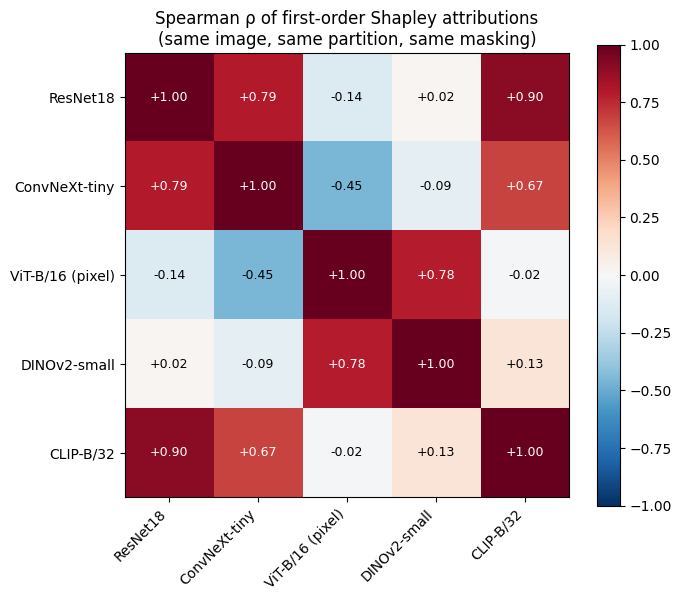

In [25]:
from scipy.stats import spearmanr

names = list(sv_per_arch.keys())
n = len(names)
rho = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        rho[i, j], _ = spearmanr(sv_per_arch[names[i]], sv_per_arch[names[j]])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(rho, cmap=cm.RdBu_r, vmin=-1, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticklabels(names)
for i in range(n):
    for j in range(n):
        ax.text(
            j,
            i,
            f"{rho[i, j]:+.2f}",
            ha="center",
            va="center",
            color="black" if abs(rho[i, j]) < 0.6 else "white",
            fontsize=9,
        )
plt.colorbar(im, ax=ax)
ax.set_title(
    "Spearman ρ of first-order Shapley attributions\n(same image, same partition, same masking)"
)
plt.tight_layout()
plt.show()

## 6. CNN vs. Transformer cluster check

We compute the average correlation within the CNN family (ResNet, ConvNeXt), within the Transformer family (ViT, DINOv2, CLIP), and across families. If architectural family is a meaningful determinant of *where* a model looks, we would expect higher within-family $\bar\rho$ than across-family $\bar\rho$.

> **Caveat (N = 1 image).** On a single image the within-family averages rest on very few pairs (one for CNN, three for Transformer), so random variation can easily overwhelm any structural signal. Treat the numbers as illustrative rather than as a claim about architecture families in general.


In [26]:
cnn = ["ResNet18", "ConvNeXt-tiny"]
tf = ["ViT-B/16 (pixel)", "DINOv2-small", "CLIP-B/32"]


def avg_rho(group_a, group_b):
    vals = []
    for a in group_a:
        for b in group_b:
            if a == b:
                continue
            i, j = names.index(a), names.index(b)
            vals.append(rho[i, j])
    return float(np.mean(vals)) if vals else float("nan")


print(f"  within-CNN         (ResNet ↔ ConvNeXt)    : ρ̄ = {avg_rho(cnn, cnn):+.3f}")
print(f"  within-Transformer (ViT/DINOv2/CLIP pairs) : ρ̄ = {avg_rho(tf, tf):+.3f}")
print(f"  across families                            : ρ̄ = {avg_rho(cnn, tf):+.3f}")

  within-CNN         (ResNet ↔ ConvNeXt)    : ρ̄ = +0.794
  within-Transformer (ViT/DINOv2/CLIP pairs) : ρ̄ = +0.297
  across families                            : ρ̄ = +0.152


## 7. Disagreement analysis — which superpixel splits the architectures?

We z-score each architecture's attributions to make the different output scales comparable, then examine which superpixel has the highest **variance** across architectures.

A note on interpretation: high variance indicates that models differ on *how strongly* they weight a region relative to their own mean, not necessarily on *whether* it matters. A player that all five architectures rank as important will have all positive z-scores, and the variance captures the spread of those positive values. A genuinely contested player would show a mix of positive and negative z-scores. Players that all models consistently rank as unimportant will cluster near zero variance.


  player   var-across-archs   z-scores (ResNet, ConvNeXt, ViT, DINOv2, CLIP)
     8        +3.948        -1.26  -1.71  +2.03  +2.31  -2.45
     4        +0.834        +0.71  +1.94  -0.74  -0.21  +0.60
     5        +0.609        +1.55  +1.36  -0.46  -0.03  +0.82
     0        +0.600        +1.19  +0.16  -0.48  -0.51  +1.26
     9        +0.249        +1.28  +0.57  +1.93  +1.36  +0.66


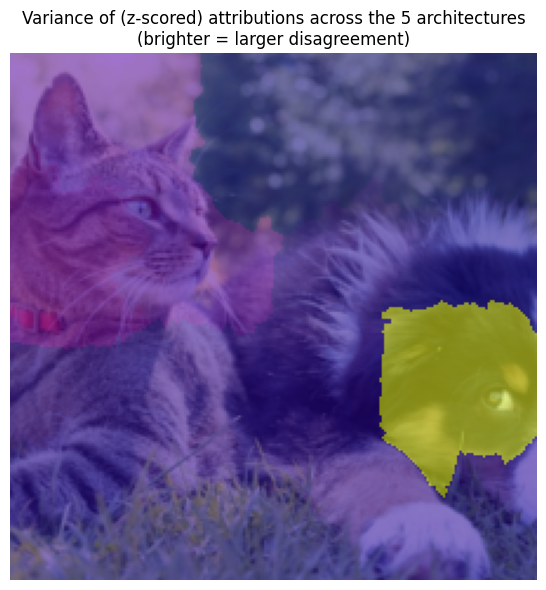

In [27]:
Z = np.stack([(sv - sv.mean()) / (sv.std() + 1e-9) for sv in sv_per_arch.values()])
var_per_player = Z.var(axis=0)
ranking = np.argsort(-var_per_player)

print("  player   var-across-archs   z-scores (ResNet, ConvNeXt, ViT, DINOv2, CLIP)")
for p in ranking[:5]:
    z = "  ".join(f"{Z[i, p]:+.2f}" for i in range(Z.shape[0]))
    print(f"   {p:>3}        {var_per_player[p]:+.3f}        {z}")

fig, ax = plt.subplots(figsize=(6, 6))
h = heatmap_from_masks(var_per_player)
ax.imshow(image)
ax.imshow(h, cmap="plasma", alpha=0.55)
ax.set_title(
    "Variance of (z-scored) attributions across the 5 architectures\n(brighter = larger disagreement)"
)
ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Same image, different target: CLIP prompt sensitivity (control)

As a control, we re-run CLIP for the prompt `"a photo of a dog"` instead of `"a photo of a cat"`. The image, partition, and masking are all unchanged.

With the current image (cat and dog together in the grass) this is a clean test: both animals are visible, so switching the target prompt should *flip* the attribution map. The dog superpixel should switch from negative to strongly positive, and the cat superpixel from positive to negative. A near-perfect anti-correlation ($\rho \approx -1$) would confirm that CLIP's explanation tracks the semantics of the prompt rather than a fixed pattern in the image encoding.


  CLIP target='cat' vs target='dog' : ρ = -0.915


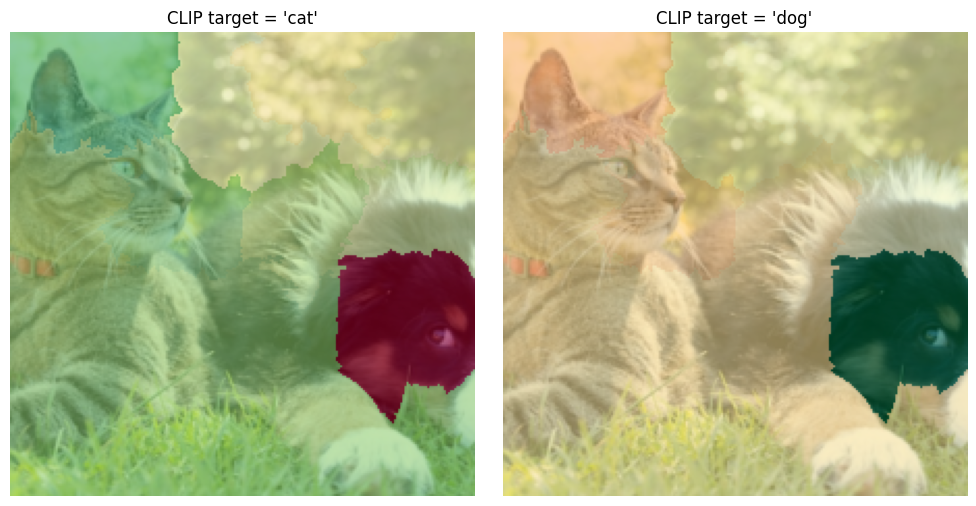

In [28]:
alt_arch = CLIPArchitecture(
    model=arch_clip.model,
    processor=arch_clip.processor,
    text_prompts=PROMPTS,
    target_prompt_idx=1,  # 'a photo of a dog' instead of 'cat'
    masking_strategy=MeanColorMasking(),
)
imp = ImageImputer(
    architecture=alt_arch, image=image, player_strategy=FixedSLIC(), batch_size=16, normalize=False
)
alt_sv_raw = ExactComputer(n_players=N_PLAYERS, game=imp).probabilistic_value(index="SV")
alt_sv = np.array([alt_sv_raw[(i,)] for i in range(N_PLAYERS)])

rho_prompt, _ = spearmanr(sv_per_arch["CLIP-B/32"], alt_sv)
print(f"  CLIP target='cat' vs target='dog' : ρ = {rho_prompt:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (label, vals) in zip(
    axes, [("cat", sv_per_arch["CLIP-B/32"]), ("dog", alt_sv)], strict=False
):
    h = heatmap_from_masks(vals)
    v = max(abs(h.min()), abs(h.max())) + 1e-9
    ax.imshow(image)
    ax.imshow(h, cmap=cm.RdYlGn, norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-v, vmax=v), alpha=0.55)
    ax.set_title(f"CLIP target = '{label}'")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 9. Discussion

### Main findings

- **Rank correlations are positive but moderate.** Even with identical players and masking, no two architectures produce identical attribution rankings. The pairwise $\rho$ values are positive overall, reflecting a mix of weak and moderate agreement, which indicates real disagreement across architectures.
- **The Transformer family tends to cluster.** The within-Transformer $\bar\rho$ may be higher than the cross-family $\bar\rho$, suggesting the three transformer architectures share more attribution structure than CNN/Transformer pairs do. The within-CNN baseline (one pair: ResNet and ConvNeXt) can sometimes fall below the cross-family average, meaning the two CNNs disagree as much as a CNN and a Transformer. This single-image finding should not be over-interpreted.
- **High-variance regions are not necessarily "disagreement" regions.** Looking at the z-scores clarifies this: if all architectures give a player positive z-scores, the variance reflects disagreement on the *degree* of importance (some architectures care more, some less, but all agree it matters). A genuinely contested player would show a mix of positive and negative z-scores across architectures. Players that all models consider unimportant tend to cluster near zero variance.
- **CLIP responds to the prompt, not to a fixed image encoding.** With a cat-and-dog image, switching the target from `"a photo of a cat"` to `"a photo of a dog"` produces a near-perfect flip of the attribution map: the dog superpixel goes from a liability to an asset, and the cat superpixel from an asset to a liability. This is a direct demonstration that the explanation is answering the question asked of the model.

### Limitations

- **Single image.** These correlations are computed on one image. Aggregating over a dataset would be the natural next step.
- **Not strictly apples-to-apples.** ViT-B/16 is normally explained in its latent-token space. Here we forced it to consume pixel-masked inputs to keep the masker constant across architectures. The comparison is fair in the experimental sense, but this is a counterfactual ViT rather than the ViT a practitioner would typically explain.
- **Score functions differ.** ResNet, ConvNeXt, and ViT use class scores, DINOv2 uses feature similarity, and CLIP uses prompt probability. Rank correlations are the only directly comparable summary across these different output spaces.

### `shapiq` and this experiment

The whole comparison amounts to one shared player strategy fed to five `ImageImputer` instances, each backed by a different `*Architecture`. Adding a sixth model requires only a few additional lines of code, as the per-model implementation details are isolated in the architecture class.